# Multi-Task Digit Recognition and Object Localization

## Goal

This notebook trains a neural network to perform two supervised tasks simultaneously:

1. Classify the handwritten digit
2. Predict the digit's bounding box inside a larger image

Each original MNIST digit is placed at a random position and scale on a 64 × 64 canvas containing noise and small distracting objects.

## Model design

The model contains:

- a shared convolutional backbone
- a digit-classification head
- a bounding-box regression head
- explicit coordinate channels for spatial reasoning

## Main evaluation metrics

### Classification

- digit accuracy

### Localization

- mean Intersection over Union, IoU
- median IoU
- percentage with IoU ≥ 0.50
- percentage with IoU ≥ 0.75
- bounding-box coordinate error

### Joint detection

A prediction is considered jointly successful when:

- the digit class is correct
- the predicted box has IoU ≥ 0.50

## Additional experiments

- naive mean-box baseline
- per-digit performance
- object-size analysis
- worst-localization inspection
- clean, standard, and heavy-clutter evaluation

In [1]:
import copy
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode

from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

CANVAS_SIZE = 64
BATCH_SIZE = 128

TRAIN_SCENES = 20_000
VALIDATION_SCENES = 4_000
TEST_SCENES = 5_000


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.5.1+cu124


In [2]:
full_training_mnist = MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_mnist = MNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    download=True
)

print("Original training images:", len(full_training_mnist))
print("Original test images:", len(test_mnist))

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:03<00:00, 2.69MB/s]


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw

Original training images: 60000
Original test images: 10000


In [3]:
split_generator = torch.Generator().manual_seed(
    RANDOM_STATE
)

shuffled_indices = torch.randperm(
    len(full_training_mnist),
    generator=split_generator
).tolist()

training_source_indices = shuffled_indices[:50_000]
validation_source_indices = shuffled_indices[50_000:]

training_source = Subset(
    full_training_mnist,
    training_source_indices
)

validation_source = Subset(
    full_training_mnist,
    validation_source_indices
)

print("Training source images:", len(training_source))
print("Validation source images:", len(validation_source))
print("Test source images:", len(test_mnist))

Training source images: 50000
Validation source images: 10000
Test source images: 10000


In [4]:
def xyxy_to_cxcywh(boxes):
    x1 = boxes[..., 0]
    y1 = boxes[..., 1]
    x2 = boxes[..., 2]
    y2 = boxes[..., 3]

    centre_x = (x1 + x2) / 2
    centre_y = (y1 + y2) / 2

    width = x2 - x1
    height = y2 - y1

    return torch.stack(
        [
            centre_x,
            centre_y,
            width,
            height
        ],
        dim=-1
    )

In [5]:
def cxcywh_to_xyxy(boxes):
    centre_x = boxes[..., 0]
    centre_y = boxes[..., 1]
    width = boxes[..., 2]
    height = boxes[..., 3]

    x1 = centre_x - width / 2
    y1 = centre_y - height / 2

    x2 = centre_x + width / 2
    y2 = centre_y + height / 2

    converted = torch.stack(
        [x1, y1, x2, y2],
        dim=-1
    )

    return converted.clamp(0, 1)

In [6]:
def aligned_box_iou(
    predicted_xyxy,
    target_xyxy
):
    intersection_x1 = torch.maximum(
        predicted_xyxy[:, 0],
        target_xyxy[:, 0]
    )

    intersection_y1 = torch.maximum(
        predicted_xyxy[:, 1],
        target_xyxy[:, 1]
    )

    intersection_x2 = torch.minimum(
        predicted_xyxy[:, 2],
        target_xyxy[:, 2]
    )

    intersection_y2 = torch.minimum(
        predicted_xyxy[:, 3],
        target_xyxy[:, 3]
    )

    intersection_width = (
        intersection_x2
        - intersection_x1
    ).clamp(min=0)

    intersection_height = (
        intersection_y2
        - intersection_y1
    ).clamp(min=0)

    intersection_area = (
        intersection_width
        * intersection_height
    )

    predicted_area = (
        (
            predicted_xyxy[:, 2]
            - predicted_xyxy[:, 0]
        ).clamp(min=0)
        *
        (
            predicted_xyxy[:, 3]
            - predicted_xyxy[:, 1]
        ).clamp(min=0)
    )

    target_area = (
        (
            target_xyxy[:, 2]
            - target_xyxy[:, 0]
        ).clamp(min=0)
        *
        (
            target_xyxy[:, 3]
            - target_xyxy[:, 1]
        ).clamp(min=0)
    )

    union_area = (
        predicted_area
        + target_area
        - intersection_area
    )

    return (
        intersection_area
        / union_area.clamp(min=1e-8)
    )

In [7]:
def crop_digit_foreground(
    image,
    threshold=0.05
):
    foreground = image[0] > threshold

    if not foreground.any():
        return image

    row_indices = torch.where(
        foreground.any(dim=1)
    )[0]

    column_indices = torch.where(
        foreground.any(dim=0)
    )[0]

    top = int(row_indices.min())
    bottom = int(row_indices.max()) + 1

    left = int(column_indices.min())
    right = int(column_indices.max()) + 1

    return image[
        :,
        top:bottom,
        left:right
    ]

In [8]:
class PlacedMNISTDataset(Dataset):
    def __init__(
        self,
        source_dataset,
        number_of_scenes,
        canvas_size=64,
        minimum_digit_height=18,
        maximum_digit_height=36,
        maximum_clutter_objects=3,
        noise_standard_deviation=0.03,
        base_seed=1_000
    ):
        self.source_dataset = source_dataset
        self.number_of_scenes = number_of_scenes

        self.canvas_size = canvas_size

        self.minimum_digit_height = (
            minimum_digit_height
        )

        self.maximum_digit_height = (
            maximum_digit_height
        )

        self.maximum_clutter_objects = (
            maximum_clutter_objects
        )

        self.noise_standard_deviation = (
            noise_standard_deviation
        )

        self.base_seed = base_seed

    def __len__(self):
        return self.number_of_scenes

    def __getitem__(self, index):
        rng = np.random.default_rng(
            self.base_seed + index
        )

        source_index = (
            index % len(self.source_dataset)
        )

        image, digit_label = (
            self.source_dataset[source_index]
        )

        digit_crop = crop_digit_foreground(
            image
        )

        original_height = (
            digit_crop.shape[-2]
        )

        original_width = (
            digit_crop.shape[-1]
        )

        target_height = int(
            rng.integers(
                self.minimum_digit_height,
                self.maximum_digit_height + 1
            )
        )

        aspect_ratio = (
            original_width
            / max(original_height, 1)
        )

        width_variation = rng.uniform(
            0.90,
            1.10
        )

        target_width = int(
            round(
                target_height
                * aspect_ratio
                * width_variation
            )
        )

        target_width = int(
            np.clip(
                target_width,
                10,
                self.canvas_size - 2
            )
        )

        target_height = min(
            target_height,
            self.canvas_size - 2
        )

        resized_digit = resize(
            digit_crop,
            size=[
                target_height,
                target_width
            ],
            interpolation=
                InterpolationMode.BILINEAR,
            antialias=True
        )

        contrast = float(
            rng.uniform(0.75, 1.00)
        )

        resized_digit = (
            resized_digit * contrast
        )

        maximum_left = (
            self.canvas_size
            - target_width
        )

        maximum_top = (
            self.canvas_size
            - target_height
        )

        left = int(
            rng.integers(
                0,
                maximum_left + 1
            )
        )

        top = int(
            rng.integers(
                0,
                maximum_top + 1
            )
        )

        canvas = torch.zeros(
            (
                1,
                self.canvas_size,
                self.canvas_size
            ),
            dtype=torch.float32
        )

        number_of_clutter_objects = int(
            rng.integers(
                0,
                self.maximum_clutter_objects + 1
            )
        )

        for _ in range(
            number_of_clutter_objects
        ):
            clutter_height = int(
                rng.integers(1, 5)
            )

            clutter_width = int(
                rng.integers(1, 5)
            )

            clutter_top = int(
                rng.integers(
                    0,
                    self.canvas_size
                    - clutter_height + 1
                )
            )

            clutter_left = int(
                rng.integers(
                    0,
                    self.canvas_size
                    - clutter_width + 1
                )
            )

            clutter_intensity = float(
                rng.uniform(0.05, 0.25)
            )

            clutter_region = canvas[
                :,
                clutter_top:
                    clutter_top
                    + clutter_height,
                clutter_left:
                    clutter_left
                    + clutter_width
            ]

            canvas[
                :,
                clutter_top:
                    clutter_top
                    + clutter_height,
                clutter_left:
                    clutter_left
                    + clutter_width
            ] = torch.maximum(
                clutter_region,
                torch.full_like(
                    clutter_region,
                    clutter_intensity
                )
            )

        digit_region = canvas[
            :,
            top:top + target_height,
            left:left + target_width
        ]

        canvas[
            :,
            top:top + target_height,
            left:left + target_width
        ] = torch.maximum(
            digit_region,
            resized_digit
        )

        if (
            self.noise_standard_deviation
            > 0
        ):
            noise = torch.tensor(
                rng.normal(
                    loc=0.0,
                    scale=
                        self.noise_standard_deviation,
                    size=canvas.shape
                ),
                dtype=torch.float32
            )

            canvas = canvas + noise

        canvas = canvas.clamp(0, 1)

        box_xyxy = torch.tensor(
            [
                left / self.canvas_size,
                top / self.canvas_size,
                (
                    left + target_width
                ) / self.canvas_size,
                (
                    top + target_height
                ) / self.canvas_size
            ],
            dtype=torch.float32
        )

        box_cxcywh = xyxy_to_cxcywh(
            box_xyxy
        )

        return (
            canvas,
            torch.tensor(
                digit_label,
                dtype=torch.long
            ),
            box_cxcywh
        )

In [9]:
training_dataset = PlacedMNISTDataset(
    source_dataset=training_source,
    number_of_scenes=TRAIN_SCENES,
    maximum_clutter_objects=3,
    noise_standard_deviation=0.03,
    base_seed=10_000
)

validation_dataset = PlacedMNISTDataset(
    source_dataset=validation_source,
    number_of_scenes=VALIDATION_SCENES,
    maximum_clutter_objects=3,
    noise_standard_deviation=0.03,
    base_seed=20_000
)

test_dataset = PlacedMNISTDataset(
    source_dataset=test_mnist,
    number_of_scenes=TEST_SCENES,
    maximum_clutter_objects=3,
    noise_standard_deviation=0.03,
    base_seed=30_000
)

print("Training scenes:", len(training_dataset))
print("Validation scenes:", len(validation_dataset))
print("Test scenes:", len(test_dataset))

Training scenes: 20000
Validation scenes: 4000
Test scenes: 5000


In [10]:
training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

## Scene generation 

The custom dataset generated:

- 20,000 training scenes
- 4,000 validation scenes
- 5,000 test scenes

Each original MNIST digit was cropped to its foreground strokes and resized to a randomly selected height between 18 and 36 pixels. Its width was determined from the original aspect ratio with a small amount of random variation.

The resized digit was then placed at a random valid position anywhere on a 64 × 64 canvas.

Each standard scene could also contain:

- between zero and three small clutter objects
- Gaussian background noise with a standard deviation of 0.03
- random variation in digit contrast

The bounding box was stored using normalised centre coordinates, width, and height:

`centre_x, centre_y, width, height`

Normalised coordinates make the target independent of the exact image resolution. A value of 0.5 always refers to the middle of the canvas, regardless of its pixel dimensions.

In [11]:
def draw_normalised_box(
    axis,
    box_cxcywh,
    canvas_size,
    linestyle="-",
    label=None,
    edgecolor="C0"
):
    box_xyxy = cxcywh_to_xyxy(
        box_cxcywh.unsqueeze(0)
    )[0]

    x1 = float(
        box_xyxy[0] * canvas_size
    )

    y1 = float(
        box_xyxy[1] * canvas_size
    )

    x2 = float(
        box_xyxy[2] * canvas_size
    )

    y2 = float(
        box_xyxy[3] * canvas_size
    )

    rectangle = Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
        linestyle=linestyle,
        edgecolor=edgecolor,
        label=label
    )

    axis.add_patch(rectangle)

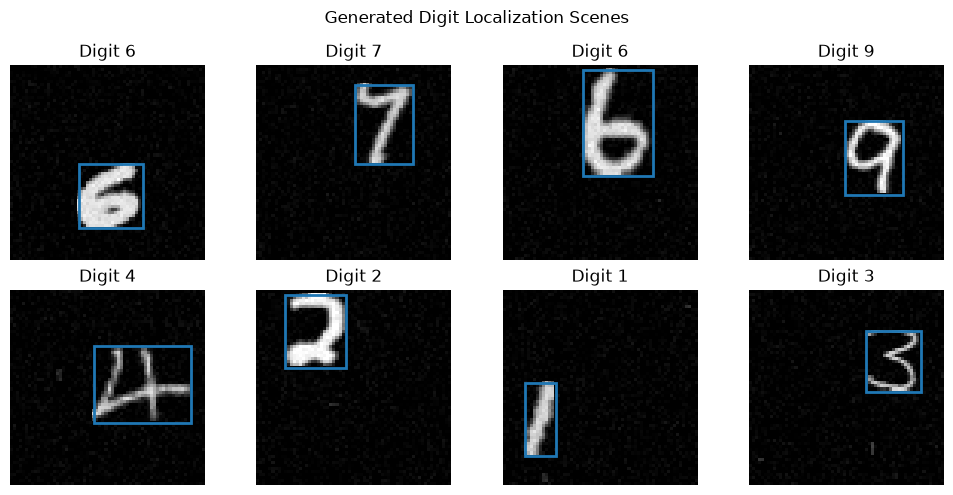

In [12]:
figure, axes = plt.subplots(
    2,
    4,
    figsize=(10, 5)
)

for scene_index, axis in enumerate(
    axes.flatten()
):
    image, label, box = (
        training_dataset[scene_index]
    )

    axis.imshow(
        image.squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    draw_normalised_box(
        axis,
        box,
        CANVAS_SIZE
    )

    axis.set_title(
        f"Digit {int(label)}"
    )

    axis.axis("off")

plt.suptitle(
    "Generated Digit Localization Scenes"
)

plt.tight_layout()
plt.show()

## Generated examples 

The generated examples showed substantial variation in digit position, scale, aspect ratio, and handwriting style.

Digits appeared near the centre, corners, edges, and other locations across the full canvas. Their sizes also varied considerably. For example, the narrow digit 1 occupied a much smaller area than wider digits such as 4 or 6.

The blue target boxes closely enclosed the actual digit strokes and excluded the small noise and clutter marks in the background.

The examples suggest that classification and localization have different difficulties:

- the digit identity may remain visually recognisable even when it is small
- accurately estimating the boundaries of a small or narrow digit is more difficult
- digits near the image boundaries provide less surrounding spatial context
- clutter must be ignored rather than included in the target box

In [13]:
baseline_sample_count = 3_000

baseline_labels = []
baseline_boxes = []

for index in range(
    baseline_sample_count
):
    _, label, box = (
        training_dataset[index]
    )

    baseline_labels.append(
        int(label)
    )

    baseline_boxes.append(box)

most_common_digit = Counter(
    baseline_labels
).most_common(1)[0][0]

mean_training_box = torch.stack(
    baseline_boxes
).mean(dim=0)

print("Most common digit:", most_common_digit)
print("Mean training box:", mean_training_box)

Most common digit: 8
Mean training box: tensor([0.4946, 0.4965, 0.3405, 0.4233])


In [14]:
test_labels_for_baseline = []
test_boxes_for_baseline = []

for index in range(len(test_dataset)):
    _, label, box = test_dataset[index]

    test_labels_for_baseline.append(
        int(label)
    )

    test_boxes_for_baseline.append(box)

test_labels_for_baseline = torch.tensor(
    test_labels_for_baseline
)

test_boxes_for_baseline = torch.stack(
    test_boxes_for_baseline
)

baseline_class_predictions = (
    torch.full_like(
        test_labels_for_baseline,
        fill_value=most_common_digit
    )
)

baseline_class_accuracy = (
    baseline_class_predictions
    == test_labels_for_baseline
).float().mean().item()

baseline_box_predictions = (
    mean_training_box
    .unsqueeze(0)
    .expand(
        len(test_dataset),
        -1
    )
)

baseline_iou = aligned_box_iou(
    cxcywh_to_xyxy(
        baseline_box_predictions
    ),
    cxcywh_to_xyxy(
        test_boxes_for_baseline
    )
)

print(
    "Naive classification accuracy:",
    round(
        baseline_class_accuracy,
        4
    )
)

print(
    "Naive mean-box IoU:",
    round(
        baseline_iou.mean().item(),
        4
    )
)

print(
    "Naive IoU >= 0.50:",
    round(
        (
            baseline_iou >= 0.50
        ).float().mean().item(),
        4
    )
)

Naive classification accuracy: 0.0978
Naive mean-box IoU: 0.2005
Naive IoU >= 0.50: 0.0712


## Naive baseline 

The naive baseline ignored the input image completely.

It always predicted:

- Digit 8, the most common digit among the sampled training scenes
- The average training bounding box

The average predicted box was:

- Centre x: 0.4946
- Centre y: 0.4965
- Width: 0.3405
- Height: 0.4233

This corresponds to a moderately sized box near the centre of the canvas.

Baseline test performance was:

- Classification accuracy: 0.0978
- Mean IoU: 0.2005
- IoU ≥ 0.50: 0.0712

The classification result was close to the expected 10% accuracy from always predicting one digit class.

The mean-box baseline occasionally overlapped the real object by chance, but fewer than 8% of its boxes reached an IoU of 0.50.

This confirms that dataset-level position and class statistics were not sufficient. The model needed to analyse each individual scene.

In [15]:
def add_coordinate_channels(images):
    batch_size, _, height, width = (
        images.shape
    )

    y_coordinates = torch.linspace(
        -1,
        1,
        height,
        device=images.device,
        dtype=images.dtype
    )

    x_coordinates = torch.linspace(
        -1,
        1,
        width,
        device=images.device,
        dtype=images.dtype
    )

    y_grid, x_grid = torch.meshgrid(
        y_coordinates,
        x_coordinates,
        indexing="ij"
    )

    x_grid = (
        x_grid
        .unsqueeze(0)
        .unsqueeze(0)
        .expand(
            batch_size,
            1,
            height,
            width
        )
    )

    y_grid = (
        y_grid
        .unsqueeze(0)
        .unsqueeze(0)
        .expand(
            batch_size,
            1,
            height,
            width
        )
    )

    return torch.cat(
        [
            images,
            x_grid,
            y_grid
        ],
        dim=1
    )

In [16]:
class MultiTaskDigitLocator(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )

        self.shared_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128 * 4 * 4,
                256
            ),
            nn.ReLU(),
            nn.Dropout(0.30)
        )

        self.classification_head = (
            nn.Linear(256, 10)
        )

        self.bounding_box_head = (
            nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 4),
                nn.Sigmoid()
            )
        )

    def forward(self, images):
        coordinate_images = (
            add_coordinate_channels(images)
        )

        features = self.backbone(
            coordinate_images
        )

        shared_representation = (
            self.shared_layers(features)
        )

        class_logits = (
            self.classification_head(
                shared_representation
            )
        )

        predicted_box = (
            self.bounding_box_head(
                shared_representation
            )
        )

        return (
            class_logits,
            predicted_box
        )

In [17]:
model = MultiTaskDigitLocator().to(
    device
)

example_images, _, _ = next(
    iter(training_loader)
)

with torch.no_grad():
    example_logits, example_boxes = model(
        example_images[:4].to(device)
    )

print(
    "Classification output:",
    example_logits.shape
)

print(
    "Bounding-box output:",
    example_boxes.shape
)

Classification output: torch.Size([4, 10])
Bounding-box output: torch.Size([4, 4])


In [18]:
BOX_LOSS_WEIGHT = 5.0
SMOOTH_L1_BETA = 0.05

In [19]:
def calculate_multitask_loss(
    class_logits,
    predicted_boxes,
    class_targets,
    box_targets
):
    classification_loss = (
        F.cross_entropy(
            class_logits,
            class_targets
        )
    )

    localization_loss = (
        F.smooth_l1_loss(
            predicted_boxes,
            box_targets,
            beta=SMOOTH_L1_BETA
        )
    )

    total_loss = (
        classification_loss
        + BOX_LOSS_WEIGHT
        * localization_loss
    )

    return (
        total_loss,
        classification_loss,
        localization_loss
    )

In [20]:
@torch.no_grad()
def evaluate_model(
    model,
    data_loader
):
    model.eval()

    total_examples = 0
    total_loss = 0.0

    correct_classes = 0
    localization_50 = 0
    localization_75 = 0
    joint_success = 0

    coordinate_absolute_error = 0.0

    all_ious = []

    for (
        images,
        class_targets,
        box_targets
    ) in data_loader:
        images = images.to(device)

        class_targets = (
            class_targets.to(device)
        )

        box_targets = (
            box_targets.to(device)
        )

        (
            class_logits,
            predicted_boxes
        ) = model(images)

        (
            loss,
            _,
            _
        ) = calculate_multitask_loss(
            class_logits,
            predicted_boxes,
            class_targets,
            box_targets
        )

        batch_size = images.shape[0]

        total_loss += (
            loss.item() * batch_size
        )

        total_examples += batch_size

        class_predictions = (
            class_logits.argmax(dim=1)
        )

        class_correct = (
            class_predictions
            == class_targets
        )

        predicted_xyxy = (
            cxcywh_to_xyxy(
                predicted_boxes
            )
        )

        target_xyxy = (
            cxcywh_to_xyxy(
                box_targets
            )
        )

        batch_ious = aligned_box_iou(
            predicted_xyxy,
            target_xyxy
        )

        correct_classes += int(
            class_correct.sum()
        )

        localization_50 += int(
            (
                batch_ious >= 0.50
            ).sum()
        )

        localization_75 += int(
            (
                batch_ious >= 0.75
            ).sum()
        )

        joint_success += int(
            (
                class_correct
                & (batch_ious >= 0.50)
            ).sum()
        )

        coordinate_absolute_error += (
            torch.abs(
                predicted_xyxy
                - target_xyxy
            ).sum().item()
        )

        all_ious.append(
            batch_ious.cpu()
        )

    all_ious = torch.cat(all_ious)

    return {
        "loss":
            total_loss / total_examples,

        "classification_accuracy":
            correct_classes
            / total_examples,

        "mean_iou":
            all_ious.mean().item(),

        "median_iou":
            all_ious.median().item(),

        "localization_at_50":
            localization_50
            / total_examples,

        "localization_at_75":
            localization_75
            / total_examples,

        "joint_success":
            joint_success
            / total_examples,

        "coordinate_mae_pixels":
            (
                coordinate_absolute_error
                / (
                    total_examples * 4
                )
                * CANVAS_SIZE
            )
    }

In [21]:
MAXIMUM_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )
)

In [22]:
best_model_state = None
best_validation_joint_success = -np.inf

epochs_without_improvement = 0

history_rows = []

In [23]:
for epoch in range(
    1,
    MAXIMUM_EPOCHS + 1
):
    model.train()

    running_loss = 0.0
    running_classification_loss = 0.0
    running_localization_loss = 0.0

    total_training_examples = 0
    training_correct = 0

    for (
        images,
        class_targets,
        box_targets
    ) in training_loader:
        images = images.to(device)

        class_targets = (
            class_targets.to(device)
        )

        box_targets = (
            box_targets.to(device)
        )

        optimizer.zero_grad()

        (
            class_logits,
            predicted_boxes
        ) = model(images)

        (
            total_loss,
            classification_loss,
            localization_loss
        ) = calculate_multitask_loss(
            class_logits,
            predicted_boxes,
            class_targets,
            box_targets
        )

        total_loss.backward()

        optimizer.step()

        batch_size = images.shape[0]

        running_loss += (
            total_loss.item()
            * batch_size
        )

        running_classification_loss += (
            classification_loss.item()
            * batch_size
        )

        running_localization_loss += (
            localization_loss.item()
            * batch_size
        )

        total_training_examples += (
            batch_size
        )

        training_correct += int(
            (
                class_logits.argmax(dim=1)
                == class_targets
            ).sum()
        )

    validation_metrics = evaluate_model(
        model,
        validation_loader
    )

    training_loss = (
        running_loss
        / total_training_examples
    )

    training_classification_accuracy = (
        training_correct
        / total_training_examples
    )

    history_rows.append({
        "epoch": epoch,
        "training_loss":
            training_loss,
        "training_classification_loss":
            running_classification_loss
            / total_training_examples,
        "training_localization_loss":
            running_localization_loss
            / total_training_examples,
        "training_accuracy":
            training_classification_accuracy,
        "validation_loss":
            validation_metrics["loss"],
        "validation_accuracy":
            validation_metrics[
                "classification_accuracy"
            ],
        "validation_mean_iou":
            validation_metrics["mean_iou"],
        "validation_joint_success":
            validation_metrics[
                "joint_success"
            ],
        "learning_rate":
            optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss "
        f"{training_loss:.4f} | "
        f"Train accuracy "
        f"{training_classification_accuracy:.4f} | "
        f"Val accuracy "
        f"{validation_metrics['classification_accuracy']:.4f} | "
        f"Val IoU "
        f"{validation_metrics['mean_iou']:.4f} | "
        f"Val joint "
        f"{validation_metrics['joint_success']:.4f}"
    )

    current_joint_success = (
        validation_metrics[
            "joint_success"
        ]
    )

    scheduler.step(
        current_joint_success
    )

    if (
        current_joint_success
        > best_validation_joint_success
    ):
        best_validation_joint_success = (
            current_joint_success
        )

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("Early stopping triggered.")
        break

Epoch 01 | Train loss 1.8321 | Train accuracy 0.4058 | Val accuracy 0.5225 | Val IoU 0.5515 | Val joint 0.3120
Epoch 02 | Train loss 0.6004 | Train accuracy 0.8690 | Val accuracy 0.8875 | Val IoU 0.6603 | Val joint 0.7960
Epoch 03 | Train loss 0.3538 | Train accuracy 0.9349 | Val accuracy 0.8662 | Val IoU 0.6845 | Val joint 0.8180
Epoch 04 | Train loss 0.2821 | Train accuracy 0.9513 | Val accuracy 0.9300 | Val IoU 0.7055 | Val joint 0.8910
Epoch 05 | Train loss 0.2242 | Train accuracy 0.9650 | Val accuracy 0.7800 | Val IoU 0.7240 | Val joint 0.7500
Epoch 06 | Train loss 0.1951 | Train accuracy 0.9700 | Val accuracy 0.9410 | Val IoU 0.6900 | Val joint 0.8675
Epoch 07 | Train loss 0.1460 | Train accuracy 0.9828 | Val accuracy 0.9750 | Val IoU 0.6843 | Val joint 0.8945
Epoch 08 | Train loss 0.1325 | Train accuracy 0.9845 | Val accuracy 0.9657 | Val IoU 0.6840 | Val joint 0.8845
Epoch 09 | Train loss 0.1227 | Train accuracy 0.9863 | Val accuracy 0.9457 | Val IoU 0.6580 | Val joint 0.8200
E

In [24]:
if best_model_state is not None:
    model.load_state_dict(
        best_model_state
    )

training_history = pd.DataFrame(
    history_rows
)

training_history

,epoch,training_loss,training_classification_loss,training_localization_loss,training_accuracy,validation_loss,validation_accuracy,validation_mean_iou,validation_joint_success,learning_rate
0,1,1.832055,1.617920,0.042827,0.40585,1.598071,0.52250,0.551453,0.3120,0.00100
1,2,0.600439,0.432960,0.033496,0.86900,0.443789,0.88750,0.660297,0.7960,0.00100
2,3,0.353820,0.218162,0.027132,0.93495,0.520159,0.86625,0.684540,0.8180,0.00100
3,4,0.282090,0.165075,0.023403,0.95125,0.324220,0.93000,0.705527,0.8910,0.00100
4,5,0.224207,0.117703,0.021301,0.96505,0.783872,0.78000,0.724005,0.7500,0.00100
5,6,0.195068,0.099260,0.019162,0.97000,0.248777,0.94100,0.690042,0.8675,0.00100
6,7,0.145987,0.059851,0.017227,0.98275,0.148105,0.97500,0.684317,0.8945,0.00050
7,8,0.132512,0.053041,0.015894,0.98445,0.175326,0.96575,0.684025,0.8845,0.00050
8,9,0.122650,0.046190,0.015292,0.98630,0.255040,0.94575,0.657993,0.8200,0.00050
9,10,0.101004,0.031913,0.013818,0.99040,0.144802,0.97975,0.653743,0.8475,0.00025


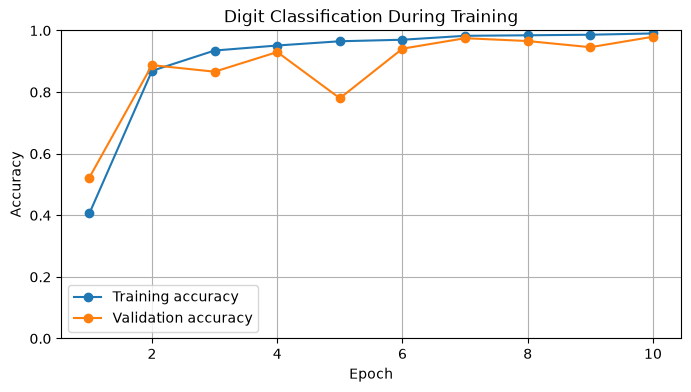

In [25]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history[
        "training_accuracy"
    ],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_accuracy"
    ],
    marker="o",
    label="Validation accuracy"
)

plt.title("Digit Classification During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

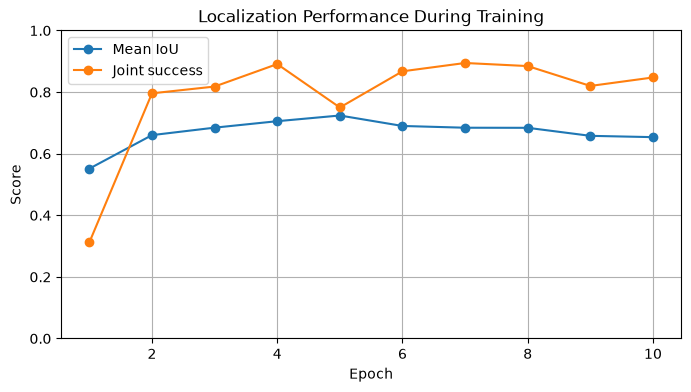

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_mean_iou"
    ],
    marker="o",
    label="Mean IoU"
)

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_joint_success"
    ],
    marker="o",
    label="Joint success"
)

plt.title("Localization Performance During Training")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Training behaviour 

Both classification and localization improved rapidly during the first few epochs, but they did not improve at exactly the same rate.

At Epoch 1, validation performance was:

- Classification accuracy: 0.5225
- Mean IoU: 0.5515
- Joint success: 0.3120

By Epoch 2, performance had already increased to:

- Classification accuracy: 0.8875
- Mean IoU: 0.6603
- Joint success: 0.7960

The highest validation mean IoU occurred at Epoch 5:

- Mean IoU: 0.7240

However, classification accuracy temporarily fell to 0.7800 during that epoch, reducing joint success to 0.7500.

The best overall validation checkpoint occurred at Epoch 7:

- Classification accuracy: 0.9750
- Mean IoU: 0.6843
- Joint success: 0.8945

This checkpoint was selected because joint success required both a correct class and an IoU of at least 0.50.

Training accuracy continued increasing and reached 0.9904 by Epoch 10. In contrast, validation localization performance declined after its earlier peak.

Early stopping was triggered after Epoch 10 because joint validation success had not exceeded the Epoch 7 result for three consecutive epochs. The Epoch 7 model weights were restored for final evaluation.

The results reveal a multi-task trade-off. Improving digit classification did not always improve bounding-box quality, and the epoch with the best mean IoU was not the epoch with the best joint result.

In [27]:
test_metrics = evaluate_model(
    model,
    test_loader
)

test_metrics_df = pd.DataFrame({
    "metric": list(
        test_metrics.keys()
    ),
    "value": list(
        test_metrics.values()
    )
})

test_metrics_df

,metric,value
0,loss,0.163709
1,classification_accuracy,0.972600
2,mean_iou,0.671710
3,median_iou,0.685815
4,localization_at_50,0.899600
5,localization_at_75,0.303000
6,joint_success,0.876600
7,coordinate_mae_pixels,2.365774


## Final test result 

The selected multi-task model achieved:

- Test loss: 0.1637
- Digit classification accuracy: 0.9726
- Mean IoU: 0.6717
- Median IoU: 0.6858
- IoU ≥ 0.50: 0.8996
- IoU ≥ 0.75: 0.3030
- Joint class-and-box success: 0.8766
- Mean bounding-box coordinate error: 2.37 pixels

Compared with the naive baseline:

| Metric | Naive baseline | Multi-task model |
|---|---:|---:|
| Classification accuracy | 0.0978 | 0.9726 |
| Mean IoU | 0.2005 | 0.6717 |
| IoU ≥ 0.50 | 0.0712 | 0.8996 |

The model improved classification accuracy by approximately 87.48 percentage points.

It also improved mean IoU by approximately 0.4712 and increased the percentage of successfully localized objects from 7.12% to 89.96%.

The 97.26% classification accuracy shows that the shared representation identified digit classes reliably despite random location, scale, noise, and clutter.

Localization was strong under the relaxed IoU threshold of 0.50, but only 30.30% of predictions reached the stricter threshold of 0.75. The model therefore usually found the correct object region, but its box boundaries were not always extremely precise.

The test joint-success rate of 87.66% was reasonably close to the best validation result of 89.45%, indicating consistent generalisation.

In [28]:
@torch.no_grad()
def collect_prediction_table(
    model,
    data_loader
):
    model.eval()

    rows = []
    dataset_index = 0

    for (
        images,
        class_targets,
        box_targets
    ) in data_loader:
        images = images.to(device)

        class_targets_device = (
            class_targets.to(device)
        )

        box_targets_device = (
            box_targets.to(device)
        )

        (
            class_logits,
            predicted_boxes
        ) = model(images)

        class_predictions = (
            class_logits.argmax(dim=1)
        )

        predicted_xyxy = (
            cxcywh_to_xyxy(
                predicted_boxes
            )
        )

        target_xyxy = (
            cxcywh_to_xyxy(
                box_targets_device
            )
        )

        ious = aligned_box_iou(
            predicted_xyxy,
            target_xyxy
        )

        box_areas = (
            box_targets_device[:, 2]
            * box_targets_device[:, 3]
        )

        coordinate_errors = (
            torch.abs(
                predicted_xyxy
                - target_xyxy
            ).mean(dim=1)
            * CANVAS_SIZE
        )

        for item_index in range(
            images.shape[0]
        ):
            true_digit = int(
                class_targets_device[
                    item_index
                ]
            )

            predicted_digit = int(
                class_predictions[
                    item_index
                ]
            )

            iou = float(
                ious[item_index]
            )

            rows.append({
                "dataset_index":
                    dataset_index,
                "true_digit":
                    true_digit,
                "predicted_digit":
                    predicted_digit,
                "correct_class":
                    true_digit
                    == predicted_digit,
                "iou":
                    iou,
                "localized_at_50":
                    iou >= 0.50,
                "joint_success":
                    (
                        true_digit
                        == predicted_digit
                        and iou >= 0.50
                    ),
                "box_area":
                    float(
                        box_areas[
                            item_index
                        ]
                    ),
                "coordinate_error_pixels":
                    float(
                        coordinate_errors[
                            item_index
                        ]
                    )
            })

            dataset_index += 1

    return pd.DataFrame(rows)

In [29]:
prediction_df = collect_prediction_table(
    model,
    test_loader
)

prediction_df.head()

,dataset_index,true_digit,predicted_digit,correct_class,iou,localized_at_50,joint_success,box_area,coordinate_error_pixels
0,0,7,7,True,0.680436,True,True,0.232422,3.153918
1,1,2,2,True,0.882752,True,True,0.265625,1.034279
2,2,1,1,True,0.563934,True,True,0.112793,3.382526
3,3,0,0,True,0.316262,False,False,0.074219,5.736259
4,4,4,4,True,0.660376,True,True,0.092285,1.988724


In [30]:
digit_performance = (
    prediction_df
    .groupby("true_digit")
    .agg(
        samples=(
            "true_digit",
            "size"
        ),
        classification_accuracy=(
            "correct_class",
            "mean"
        ),
        mean_iou=(
            "iou",
            "mean"
        ),
        localization_at_50=(
            "localized_at_50",
            "mean"
        ),
        joint_success=(
            "joint_success",
            "mean"
        ),
        coordinate_error_pixels=(
            "coordinate_error_pixels",
            "mean"
        )
    )
    .reset_index()
)

digit_performance

,true_digit,samples,classification_accuracy,mean_iou,localization_at_50,joint_success,coordinate_error_pixels
0,0,460,0.982609,0.703752,0.936957,0.919565,2.225622
1,1,571,0.984238,0.594543,0.754816,0.742557,2.351890
2,2,530,0.981132,0.704376,0.941509,0.926415,2.321724
3,3,500,0.984000,0.679516,0.920000,0.908000,2.342177
4,4,500,0.984000,0.680767,0.926000,0.912000,2.340011
5,5,456,0.964912,0.678933,0.925439,0.894737,2.544380
6,6,462,0.982684,0.661746,0.880952,0.863636,2.520165
7,7,512,0.953125,0.677679,0.925781,0.886719,2.370518
8,8,489,0.973415,0.673714,0.903885,0.879346,2.369947
9,9,520,0.936538,0.673344,0.901923,0.853846,2.294967


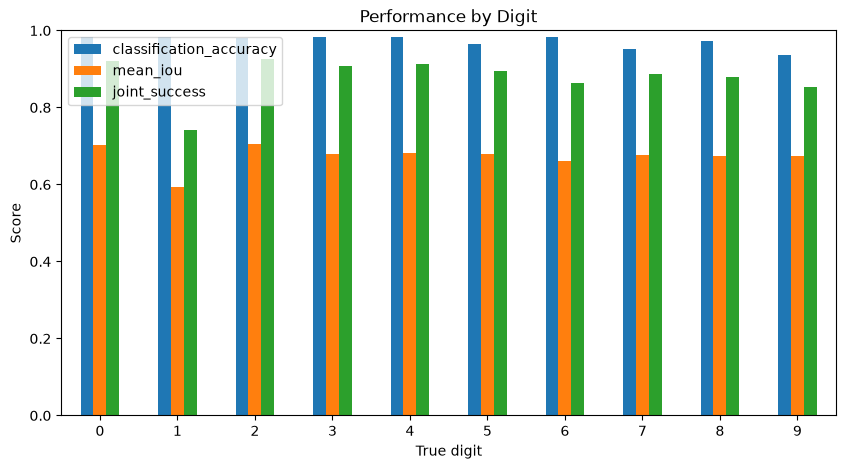

In [31]:
digit_performance.set_index(
    "true_digit"
)[
    [
        "classification_accuracy",
        "mean_iou",
        "joint_success"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Performance by Digit")
plt.xlabel("True digit")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Digit-level performance 

Digit-level performance showed that classification difficulty and localization difficulty did not necessarily match.

### Classification

The easiest digit to classify was Digit 1:

- Classification accuracy: 0.9842

Digits 3 and 4 were close behind, both achieving accuracy of 0.9840.

The hardest digit to classify was Digit 9:

- Classification accuracy: 0.9365

### Localization

The best-localized digit was Digit 2:

- Mean IoU: 0.7044
- IoU ≥ 0.50: 0.9415
- Joint success: 0.9264

Digit 0 achieved a very similar mean IoU of 0.7038.

The weakest-localized digit was Digit 1:

- Mean IoU: 0.5945
- IoU ≥ 0.50: 0.7548
- Joint success: 0.7426

This is a particularly important result. Digit 1 was the easiest class to recognise but the hardest object to localise.

Its narrow shape means that even a small horizontal shift or width error can substantially reduce IoU. The model can correctly identify a thin vertical stroke as a 1 while still predicting an inaccurate bounding box.

Digit 9 showed the opposite pattern: it had the weakest classification accuracy but localization performance close to the overall average.

The results demonstrate that semantic recognition and spatial boundary estimation are related but distinct tasks.

In [32]:
first_area_boundary = (
    prediction_df[
        "box_area"
    ].quantile(1 / 3)
)

second_area_boundary = (
    prediction_df[
        "box_area"
    ].quantile(2 / 3)
)

In [33]:
prediction_df["object_size"] = np.select(
    [
        prediction_df["box_area"]
        <= first_area_boundary,

        prediction_df["box_area"]
        <= second_area_boundary
    ],
    [
        "Small",
        "Medium"
    ],
    default="Large"
)

In [34]:
size_performance = (
    prediction_df
    .groupby(
        "object_size",
        observed=True
    )
    .agg(
        scenes=(
            "object_size",
            "size"
        ),
        classification_accuracy=(
            "correct_class",
            "mean"
        ),
        mean_iou=(
            "iou",
            "mean"
        ),
        joint_success=(
            "joint_success",
            "mean"
        ),
        coordinate_error_pixels=(
            "coordinate_error_pixels",
            "mean"
        )
    )
    .reindex(
        [
            "Small",
            "Medium",
            "Large"
        ]
    )
)

size_performance

,scenes,classification_accuracy,mean_iou,joint_success,coordinate_error_pixels
object_size,,,,,
Small,1667,0.974205,0.582748,0.734253,2.537014
Medium,1671,0.973070,0.684108,0.929384,2.304073
Large,1662,0.970517,0.748473,0.966306,2.256053


## Object-size analysis 

Object size had very little effect on classification accuracy but a strong effect on localization.

| Object size | Scenes | Accuracy | Mean IoU | Joint success | Coordinate error |
|---|---:|---:|---:|---:|---:|
| Small | 1,667 | 0.9742 | 0.5827 | 0.7343 | 2.54 pixels |
| Medium | 1,671 | 0.9731 | 0.6841 | 0.9294 | 2.30 pixels |
| Large | 1,662 | 0.9705 | 0.7485 | 0.9663 | 2.26 pixels |

Classification remained approximately 97% for all three size groups. The model therefore recognised small digits almost as reliably as large digits.

Localization behaved very differently:

- Small-object mean IoU: 0.5827
- Medium-object mean IoU: 0.6841
- Large-object mean IoU: 0.7485

Joint success increased from 73.43% for small objects to 96.63% for large objects.

The absolute coordinate error changed by less than one pixel between the groups, but the same error has a much larger proportional effect on a small box. Moving the boundary of a narrow digit by two pixels can remove a large percentage of its overlap.

This explains why small objects had much lower IoU even though their classification accuracy remained high.

In [35]:
@torch.no_grad()
def plot_model_predictions(
    model,
    dataset,
    indices,
    title
):
    model.eval()

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(11, 6)
    )

    for axis, index in zip(
        axes.flatten(),
        indices
    ):
        image, true_digit, target_box = (
            dataset[int(index)]
        )

        (
            class_logits,
            predicted_box
        ) = model(
            image
            .unsqueeze(0)
            .to(device)
        )

        predicted_digit = int(
            class_logits.argmax(dim=1)
        )

        predicted_box = (
            predicted_box[0].cpu()
        )

        iou = float(
            aligned_box_iou(
                cxcywh_to_xyxy(
                    predicted_box.unsqueeze(0)
                ),
                cxcywh_to_xyxy(
                    target_box.unsqueeze(0)
                )
            )[0]
        )

        axis.imshow(
            image.squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        draw_normalised_box(
            axis,
            target_box,
            CANVAS_SIZE,
            linestyle="-",
            label="Target",
            edgecolor="C0"
        )

        draw_normalised_box(
            axis,
            predicted_box,
            CANVAS_SIZE,
            linestyle="--",
            label="Prediction",
            edgecolor="C1"
        )

        axis.set_title(
            f"True {int(true_digit)} | "
            f"Pred {predicted_digit}\n"
            f"IoU {iou:.2f}"
        )

        axis.axis("off")

    handles, labels = (
        axes[0, 0]
        .get_legend_handles_labels()
    )

    figure.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2
    )

    plt.suptitle(title)

    plt.tight_layout(
        rect=[0, 0.06, 1, 0.95]
    )

    plt.show()

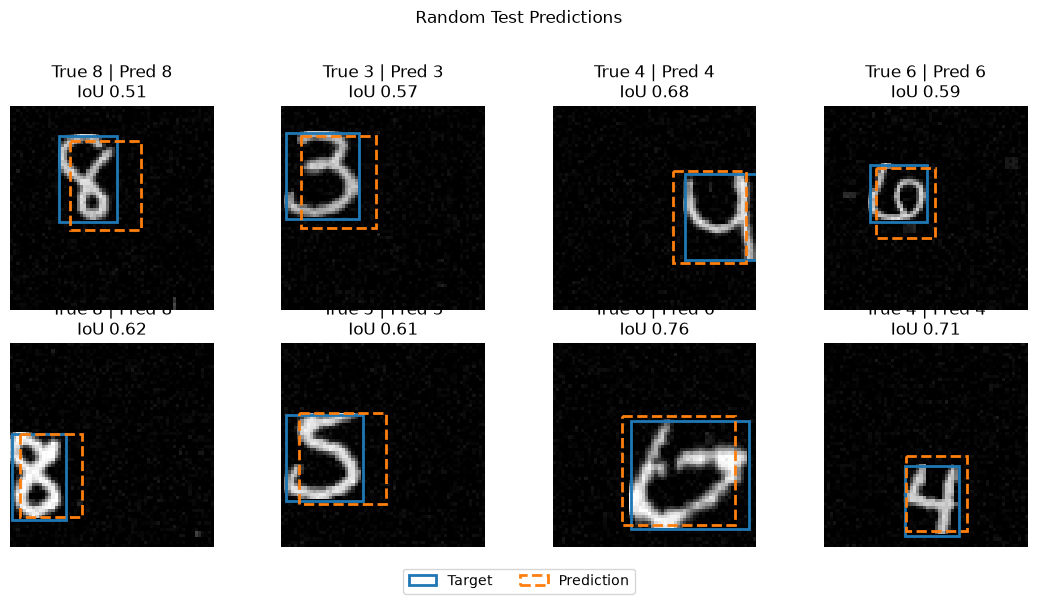

In [36]:
visual_rng = np.random.default_rng(
    RANDOM_STATE
)

random_test_indices = visual_rng.choice(
    len(test_dataset),
    size=8,
    replace=False
)

plot_model_predictions(
    model,
    test_dataset,
    random_test_indices,
    "Random Test Predictions"
)

## Visual predictions 

All eight randomly selected test examples were classified correctly.

Their IoU scores ranged from approximately 0.51 to 0.76, meaning every displayed prediction passed the 0.50 localization threshold.

The predicted boxes generally covered the correct digit and followed its approximate location and scale. Several predictions showed small boundary differences:

- some boxes were slightly wider than the target
- some were shifted horizontally or vertically
- some overestimated the digit height
- some captured the correct centre but used a less accurate size

The model also successfully localized digits placed close to the left and right image boundaries.

The small clutter marks visible in the scenes did not appear to attract the predicted boxes in these examples. The network focused on the brighter and structurally coherent digit strokes.

The visual results match the numerical evaluation: the model usually found the correct object region, although its boundaries were often not precise enough to reach very high IoU values.

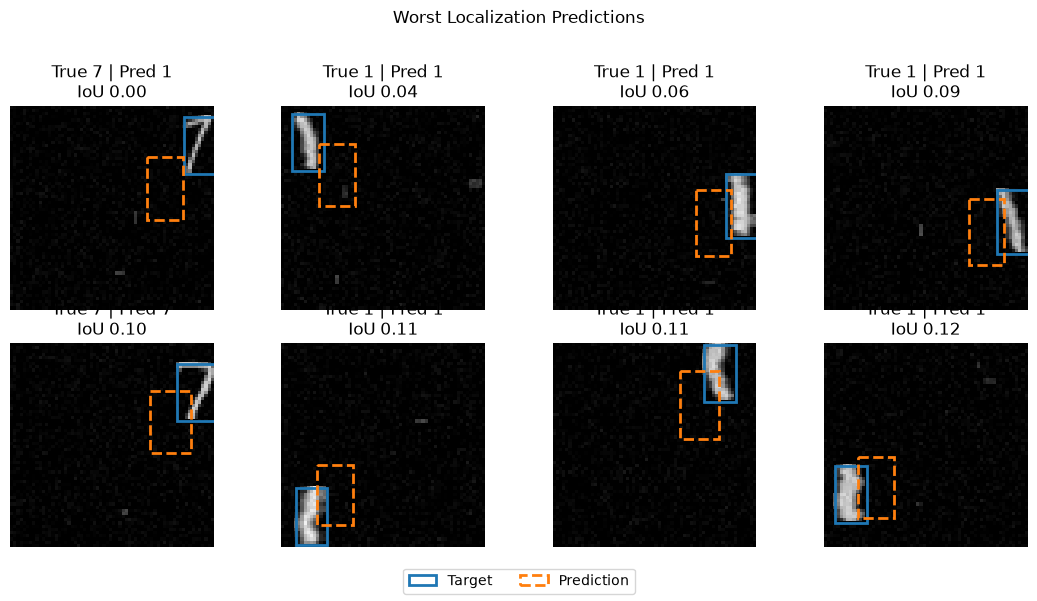

In [37]:
worst_localization_indices = (
    prediction_df
    .nsmallest(8, "iou")[
        "dataset_index"
    ]
    .to_numpy()
)

plot_model_predictions(
    model,
    test_dataset,
    worst_localization_indices,
    "Worst Localization Predictions"
)

In [38]:
prediction_df.nsmallest(
    15,
    "iou"
)[
    [
        "dataset_index",
        "true_digit",
        "predicted_digit",
        "correct_class",
        "iou",
        "box_area",
        "coordinate_error_pixels"
    ]
]

,dataset_index,true_digit,predicted_digit,correct_class,iou,box_area,coordinate_error_pixels
3213,3213,7,1,False,0.000000,0.043945,12.146615
2674,2674,1,1,True,0.036500,0.043945,9.609257
1835,1835,1,1,True,0.055880,0.048828,7.124907
31,31,1,1,True,0.086561,0.048828,5.788771
1359,1359,7,7,True,0.096243,0.052734,8.674440
1189,1189,1,1,True,0.110385,0.043945,7.048543
4729,4729,1,1,True,0.113262,0.043945,8.200126
4595,4595,1,1,True,0.123514,0.043945,5.099325
471,471,9,9,True,0.137775,0.048340,8.054441
623,623,6,6,True,0.153949,0.052734,7.670190


## Failure analysis 

The worst localization cases were dominated by very small and narrow objects.

Of the 15 lowest-IoU predictions:

- 11 involved Digit 1
- most target areas were between approximately 0.044 and 0.062 of the canvas
- 14 were still classified correctly
- only the worst example was also misclassified, with Digit 7 predicted as Digit 1

The lowest-IoU example had:

- True digit: 7
- Predicted digit: 1
- IoU: 0.0000
- Coordinate error: 12.15 pixels

Many of the worst cases occurred when the digit was very close to an image edge. The predicted box was often shifted inward toward the central region of the canvas, producing little or no overlap with the real box.

This suggests a regression-to-the-average tendency in the localization head. When uncertain, it sometimes predicted a more central box rather than following an extreme edge position.

Several examples had correct classifications but IoU values below 0.20. This confirms that the classification head could recognise the digit from its visual pattern even when the localization head failed to estimate its position.

The main failure patterns were:

- narrow Digit 1 objects
- very small bounding boxes
- objects touching or approaching canvas boundaries
- predicted boxes shifted toward the image centre
- correct object centres but inaccurate widths or heights
- occasional confusion between narrow 7s and 1s

The failures were caused more by object geometry and edge position than by background clutter in the displayed examples.

In [39]:
robustness_datasets = {
    "Clean":
        PlacedMNISTDataset(
            source_dataset=test_mnist,
            number_of_scenes=2_000,
            maximum_clutter_objects=0,
            noise_standard_deviation=0.00,
            base_seed=50_000
        ),

    "Standard":
        PlacedMNISTDataset(
            source_dataset=test_mnist,
            number_of_scenes=2_000,
            maximum_clutter_objects=3,
            noise_standard_deviation=0.03,
            base_seed=50_000
        ),

    "Heavy clutter":
        PlacedMNISTDataset(
            source_dataset=test_mnist,
            number_of_scenes=2_000,
            maximum_clutter_objects=10,
            noise_standard_deviation=0.08,
            base_seed=50_000
        )
}

In [40]:
robustness_rows = []

for condition_name, condition_dataset in (
    robustness_datasets.items()
):
    condition_loader = DataLoader(
        condition_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    condition_metrics = evaluate_model(
        model,
        condition_loader
    )

    robustness_rows.append({
        "condition":
            condition_name,
        "classification_accuracy":
            condition_metrics[
                "classification_accuracy"
            ],
        "mean_iou":
            condition_metrics[
                "mean_iou"
            ],
        "localization_at_50":
            condition_metrics[
                "localization_at_50"
            ],
        "joint_success":
            condition_metrics[
                "joint_success"
            ],
        "coordinate_mae_pixels":
            condition_metrics[
                "coordinate_mae_pixels"
            ]
    })

robustness_df = pd.DataFrame(
    robustness_rows
)

robustness_df

,condition,classification_accuracy,mean_iou,localization_at_50,joint_success,coordinate_mae_pixels
0,Clean,0.973,0.683385,0.8910,0.8695,2.247728
1,Standard,0.972,0.671010,0.8845,0.8620,2.375534
2,Heavy clutter,0.796,0.488149,0.4780,0.4255,4.772658


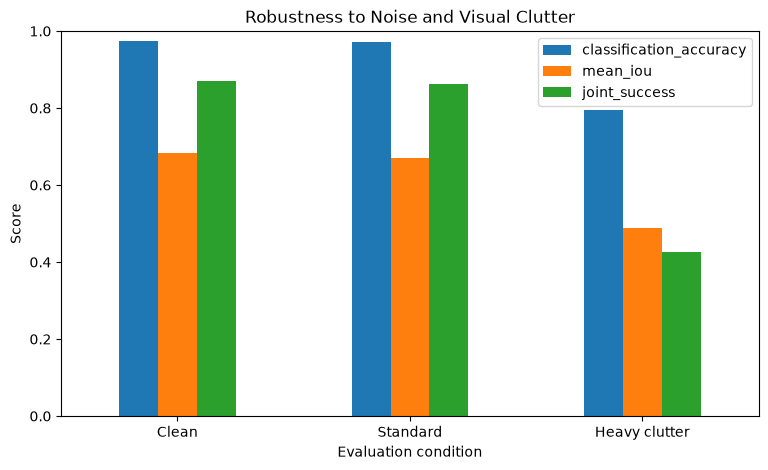

In [41]:
robustness_df.set_index(
    "condition"
)[
    [
        "classification_accuracy",
        "mean_iou",
        "joint_success"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Robustness to Noise and Visual Clutter")
plt.xlabel("Evaluation condition")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Clutter robustness 

The model was evaluated under three scene conditions:

| Condition | Accuracy | Mean IoU | IoU ≥ 0.50 | Joint success | Coordinate error |
|---|---:|---:|---:|---:|---:|
| Clean | 0.9730 | 0.6834 | 0.8910 | 0.8695 | 2.25 pixels |
| Standard | 0.9720 | 0.6710 | 0.8845 | 0.8620 | 2.38 pixels |
| Heavy clutter | 0.7960 | 0.4881 | 0.4780 | 0.4255 | 4.77 pixels |

Performance was very similar between clean and standard scenes.

Moving from clean to standard conditions changed:

- Accuracy from 0.9730 to 0.9720
- Mean IoU from 0.6834 to 0.6710
- Joint success from 0.8695 to 0.8620

This shows that the model handled the noise and clutter distribution used during training effectively.

Heavy clutter produced a major decline:

- Classification accuracy fell to 0.7960
- Mean IoU fell below 0.50
- Localization success fell to 0.4780
- Joint success fell to 0.4255
- Coordinate error more than doubled to 4.77 pixels

Heavy clutter affected both tasks, but localization was affected more strongly.

From clean to heavy-clutter conditions:

- Classification accuracy decreased by 17.7 percentage points
- IoU ≥ 0.50 decreased by 41.3 percentage points
- Joint success decreased by 44.4 percentage points

The heavy condition contained up to ten clutter objects and substantially stronger noise than the training distribution. It therefore represents an out-of-distribution stress test rather than ordinary test data.

The results show that the model was robust to familiar clutter levels but did not generalise reliably to much more severe visual interference.